In [1]:
import pandas as pd

dataset = pd.read_csv("../data/auto_mpg.csv")
dataset.head()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


In [2]:
# Tamaño del dataset

dataset.shape

(398, 8)

In [3]:
# Búsqueda de valores nulos

dataset.isna().sum()


MPG             0
Cylinders       0
Displacement    0
Horsepower      6
Weight          0
Acceleration    0
Model Year      0
Origin          0
dtype: int64

In [4]:
# Remoción de valores nulos

dataset = dataset.dropna()
dataset.isna().sum()


MPG             0
Cylinders       0
Displacement    0
Horsepower      0
Weight          0
Acceleration    0
Model Year      0
Origin          0
dtype: int64

In [5]:
# Columna Origin
# Nota:  1) USA
#        2) Europe
#        3) Japan

dataset.Origin.value_counts()


Origin
1    245
3     79
2     68
Name: count, dtype: int64

In [6]:
# Genera variables dummy para indicar la procedencia (Pésima solución)

dataset = pd.get_dummies(dataset, columns=["Origin"], prefix="", prefix_sep="")
dataset.head()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,1,2,3
0,18.0,8,307.0,130.0,3504.0,12.0,70,True,False,False
1,15.0,8,350.0,165.0,3693.0,11.5,70,True,False,False
2,18.0,8,318.0,150.0,3436.0,11.0,70,True,False,False
3,16.0,8,304.0,150.0,3433.0,12.0,70,True,False,False
4,17.0,8,302.0,140.0,3449.0,10.5,70,True,False,False


In [7]:
train_dataset = dataset.sample(frac=0.8, random_state=0)
test_dataset = dataset.drop(train_dataset.index)

In [8]:
# Las millas por galon (MPG) son función de las demas variables.

import matplotlib.pyplot as plt
import seaborn as sns

sns.pairplot(
    train_dataset[["MPG", "Cylinders", "Displacement", "Weight"]], diag_kind="kde")

plt.show()

c:\Users\juanv\OneDrive\Documentos\GitHub\std-juan-jose-vargas-sanchez\venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\juanv\OneDrive\Documentos\GitHub\std-juan-jose-vargas-sanchez\venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\juanv\OneDrive\Documentos\GitHub\std-juan-jose-vargas-sanchez\venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\juanv\OneDrive\Documentos\GitHub\std-jua

<Figure size 1000x1000 with 20 Axes>

In [9]:
# Cálculo de algunas estadísticas generales

train_dataset.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
MPG,314.0,23.310510,7.728652,10.0,17.00,22.0,28.95,46.6
Cylinders,314.0,5.477707,1.699788,3.0,4.00,4.0,8.00,8.0
Displacement,314.0,195.318471,104.331589,68.0,105.50,151.0,265.75,455.0
Horsepower,314.0,104.869427,38.096214,46.0,76.25,94.5,128.00,225.0
Weight,314.0,2990.251592,843.898596,1649.0,2256.50,2822.5,3608.00,5140.0
Acceleration,314.0,15.559236,2.789230,8.0,13.80,15.5,17.20,24.8
Model Year,314.0,75.898089,3.675642,70.0,73.00,76.0,79.00,82.0


In [10]:
# Particionamiento de los datos en features y labels

train_features = train_dataset.copy()
train_labels = train_features.pop("MPG")

test_features = test_dataset.copy()
test_labels = test_features.pop("MPG")

In [11]:
# Estandarización de los datos (normalización)

train_dataset.describe().transpose()[["mean", "std"]]


,mean,std
MPG,23.310510,7.728652
Cylinders,5.477707,1.699788
Displacement,195.318471,104.331589
Horsepower,104.869427,38.096214
Weight,2990.251592,843.898596
Acceleration,15.559236,2.789230
Model Year,75.898089,3.675642


In [12]:
# Efecto del StandardScaler

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

pd.DataFrame(
    data=scaler.fit_transform(train_dataset),
    columns=train_dataset.columns,
).describe().transpose()[["mean", "std"]]


,mean,std
MPG,-2.206303e-16,1.001596
Cylinders,2.022444e-16,1.001596
Displacement,7.990777e-17,1.001596
Horsepower,-1.980016e-17,1.001596
Weight,-9.051500e-17,1.001596
Acceleration,-5.275327e-16,1.001596
Model Year,9.419217e-16,1.001596
1,1.697156e-17,1.001596
2,3.394312e-17,1.001596
3,2.828594e-18,1.001596


In [13]:
  # Regresión lineal con una sola variable (Horsepower)
horsepower_scaler = StandardScaler()

train_horsepower = train_features[["Horsepower"]]
test_horsepower = test_features[["Horsepower"]]
horsepower_scaler.fit(train_horsepower)

standarized_train_horsepower = horsepower_scaler.transform(train_horsepower)
standarized_test_horsepower = horsepower_scaler.transform(test_horsepower)

In [14]:
# Modelo de regresión lineal

from sklearn.linear_model import LinearRegression

horsepower_model = LinearRegression()
horsepower_model.fit(standarized_train_horsepower, train_labels)


LinearRegression()

In [15]:
# Intercepto
horsepower_model.intercept_

23.31050955414013

In [16]:
# Coeficientes
horsepower_model.coef_

array([-5.89948889])

In [17]:
import numpy as np

x = pd.DataFrame({"Horsepower": np.linspace(0, 250, 251)})
x.head()

,Horsepower
0,0.0
1,1.0
2,2.0
3,3.0
4,4.0


In [18]:
# Predicción

scaled_x = horsepower_scaler.transform(x)
y = horsepower_model.predict(scaled_x)
y[:5]


array([39.57626034, 39.42115555, 39.26605075, 39.11094596, 38.95584117])

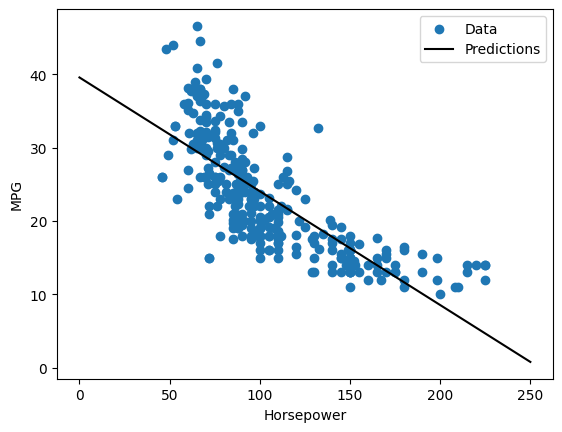

In [19]:
import matplotlib.pyplot as plt


def plot_horsepower(x, y):
    plt.scatter(train_features["Horsepower"], train_labels, label="Data")
    plt.plot(x, y, color="k", label="Predictions")
    plt.xlabel("Horsepower")
    plt.ylabel("MPG")
    plt.legend()
    
    
    
    
    

plot_horsepower(x, y)

In [20]:
# Evaluación

from sklearn.metrics import mean_squared_error

test_results = {}

y_pred = horsepower_model.predict(standarized_test_horsepower)

test_results["horsepower_model"] = mean_squared_error(
    y_true=test_labels,
    y_pred=y_pred,
)

test_results

{'horsepower_model': 20.829300555790315}

In [21]:
# Regresión lineal con todas las variables

features_scaler = StandardScaler()

features_scaler.fit(train_features)

standarized_train_features = features_scaler.transform(train_features)
standarized_test_features = features_scaler.transform(test_features)

linear_model = LinearRegression()
linear_model.fit(standarized_train_features, train_labels)

LinearRegression()

In [22]:
# Intercepto
linear_model.intercept_

23.310509554140125

In [23]:
# Coeficientes
linear_model.coef_

array([-0.78715361,  2.40329414, -1.35280162, -5.10984346, -0.26461302,
        2.92072687, -0.80879752,  0.42671757,  0.57369578])

In [24]:
def plot_predictions(y_true, y_pred):

    ax = plt.axes(aspect="equal")
    plt.scatter(y_true, y_pred)
    plt.xlabel("True Values [MPG]")
    plt.ylabel("Predictions [MPG]")
    lims = [0, 50]
    plt.xlim(lims)
    plt.ylim(lims)
    _ = plt.plot(lims, lims)
    

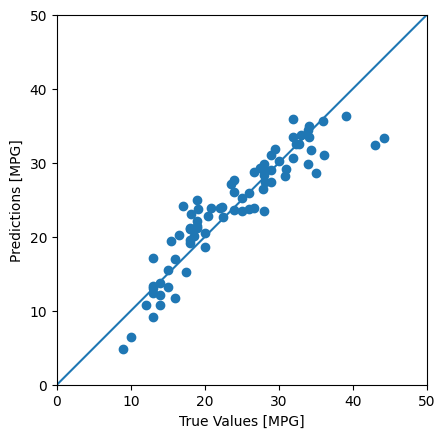

In [25]:
test_predictions = linear_model.predict(standarized_test_features)

plot_predictions(
    y_true=test_labels,
    y_pred=test_predictions,
) 

In [26]:
test_results["linear_model"] = mean_squared_error(
      y_true=test_labels,
      y_pred=test_predictions,
  )

test_results


{'horsepower_model': 20.829300555790315, 'linear_model': 10.172092283687604}

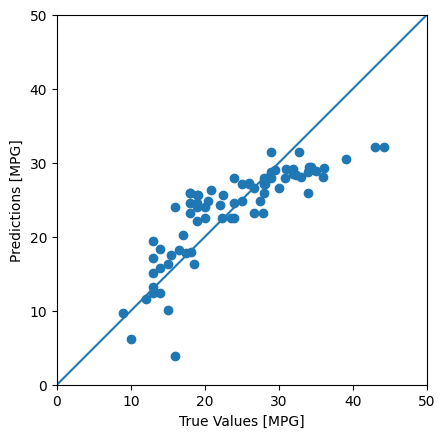

In [27]:
plot_predictions(
    y_true=test_labels,
    y_pred=horsepower_model.predict(standarized_test_horsepower),
)


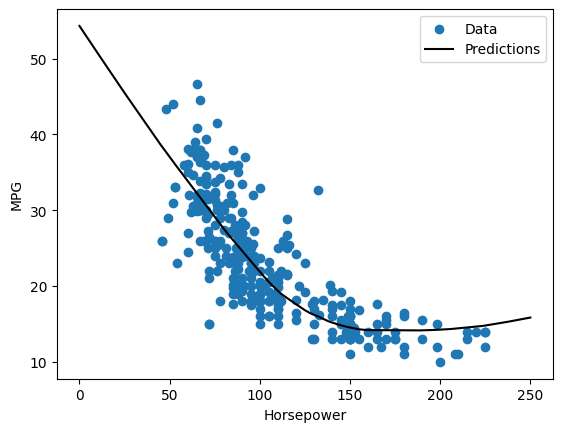

In [28]:
# Red neuronal con una sola entrada (Horsepower)

from sklearn.neural_network import MLPRegressor

mlp_horsepower = MLPRegressor(
    max_iter=10000,
    hidden_layer_sizes=(64, 64),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    validation_fraction=0.2,
    early_stopping=True,
    random_state=0,
)
mlp_horsepower.fit(standarized_train_horsepower, train_labels)

y = mlp_horsepower.predict(scaled_x)
plot_horsepower(x, y)




In [29]:
y_pred = mlp_horsepower.predict(standarized_test_horsepower)

test_results["mlp_horsepower"] = mean_squared_error(
    y_true=test_labels,
    y_pred=y_pred,
)

test_results

{'horsepower_model': 20.829300555790315,
 'linear_model': 10.172092283687604,
 'mlp_horsepower': 12.806525974883083}

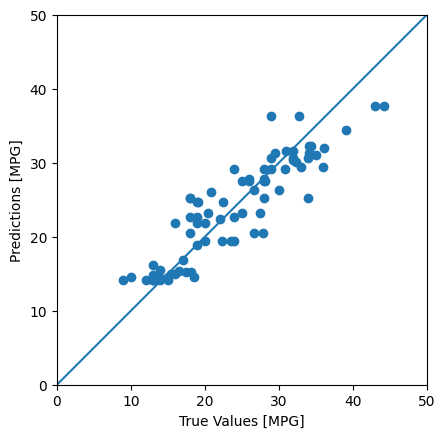

In [30]:
plot_predictions(
    y_true=test_labels,
    y_pred=mlp_horsepower.predict(standarized_test_horsepower),
)

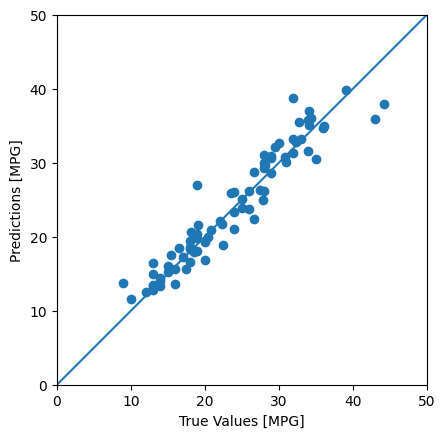

In [31]:
# Red neuronal con todas las variables

mlp = MLPRegressor(
    max_iter=10000,
    hidden_layer_sizes=(64, 64),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    validation_fraction=0.2,
    early_stopping=True,
    random_state=0,
)

mlp.fit(standarized_train_features, train_labels)

test_predictions = mlp.predict(standarized_test_features)

plot_predictions(
    y_true=test_labels,
    y_pred=test_predictions,
)


In [32]:
test_results["mlp"] = mean_squared_error(
    y_true=test_labels,
    y_pred=test_predictions,
)

In [33]:
# almacenamiento de los modelos y del scaler de features

import os
import pickle


with open("../submission/mlp.pkl", "wb") as file:
    pickle.dump(mlp, file)

with open("../submission/features_scaler.pkl", "wb") as file:
    pickle.dump(features_scaler, file)


In [34]:
# Uso del modelo

import pandas as pd

dataset = pd.read_csv("../data/auto_mpg.csv")
dataset = dataset.dropna()
dataset["Origin"] = dataset["Origin"].map(
    {1: "USA", 2: "Europe", 3: "Japan"},
)
dataset = pd.get_dummies(dataset, columns=["Origin"], prefix="", prefix_sep="")
y_true = dataset.pop("MPG")

with open("../submission/mlp.pkl", "rb") as file:
    new_mlp = pickle.load(file)

with open("../submission/features_scaler.pkl", "rb") as file:
    new_features_scaler = pickle.load(file)

standarized_dataset = new_features_scaler.transform(dataset)
y_pred = new_mlp.predict(standarized_dataset)

mean_squared_error(
    y_true=y_true,
    y_pred=y_pred,
)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Europe
- Japan
- USA
Feature names seen at fit time, yet now missing:
- 1
- 2
- 3
